In [1]:
# Added necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
from collections import Counter
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense, Dropout, BatchNormalization, MaxPooling2D
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from imblearn.over_sampling import SMOTE
import seaborn as sns
import tensorflow as tf

In [3]:
# Loading the data files

non_demented_paths = [r'C:/Users/sarat/Downloads/Data 1/Data/Non Demented/' + f for f in os.listdir(r'C:/Users/sarat/Downloads/Data 1/Data/Non Demented')]
very_mild_demented_paths = [r'C:/Users/sarat/Downloads/Data 1/Data/Very mild Dementia/' + f for f in os.listdir(r'C:/Users/sarat/Downloads/Data 1/Data/Very mild Dementia')]
mild_demented_paths = [r'C:/Users/sarat/Downloads/Data 1/Data/Mild Dementia/' + f for f in os.listdir(r'C:/Users/sarat/Downloads/Data 1/Data/Mild Dementia')]
moderate_demented_paths = [r'C:/Users/sarat/Downloads/Data 1/Data/Moderate Dementia/' + f for f in os.listdir(r'C:/Users/sarat/Downloads/Data 1/Data/Moderate Dementia')]

# Combined paths and labels
image_paths = non_demented_paths + very_mild_demented_paths + mild_demented_paths + moderate_demented_paths
labels = [0] * len(non_demented_paths) + [1] * len(very_mild_demented_paths) + [2] * len(mild_demented_paths) + [3] * len(moderate_demented_paths)

In [3]:
# Display class distribution
print("Class Distribution:")
print("Non Demented:", len(non_demented_paths))
print("Very Mild Demented:", len(very_mild_demented_paths))
print("Mild Demented:", len(mild_demented_paths))
print("Moderate Demented:", len(moderate_demented_paths))

Class Distribution:
Non Demented: 67222
Very Mild Demented: 13725
Mild Demented: 5002
Moderate Demented: 488


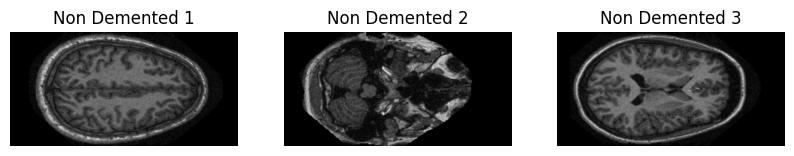

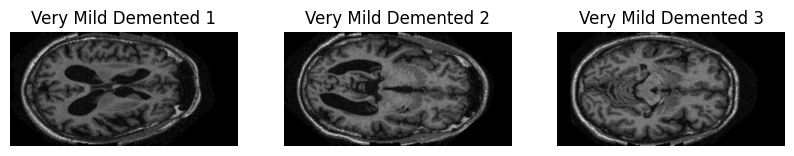

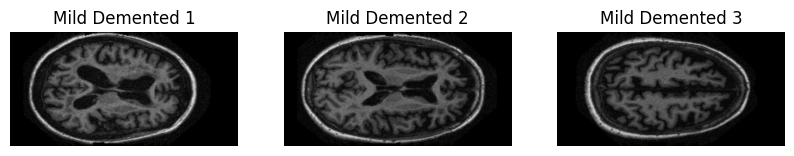

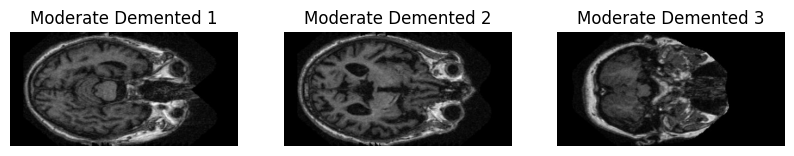

In [ ]:
# Visualize Sample Images
def display_sample_images(paths, title):
    plt.figure(figsize=(10, 5))
    for i, path in enumerate(random.sample(paths, 3)):
        img = Image.open(path)
        plt.subplot(1, 3, i+1)
        plt.imshow(img)
        plt.title(f"{title} {i+1}")
        plt.axis('off')
    plt.show()

display_sample_images(non_demented_paths, "Non Demented")
display_sample_images(very_mild_demented_paths, "Very Mild Demented")
display_sample_images(mild_demented_paths, "Mild Demented")
display_sample_images(moderate_demented_paths, "Moderate Demented")

Original class distribution: Counter({0: 67222, 1: 13725, 2: 5002, 3: 488})


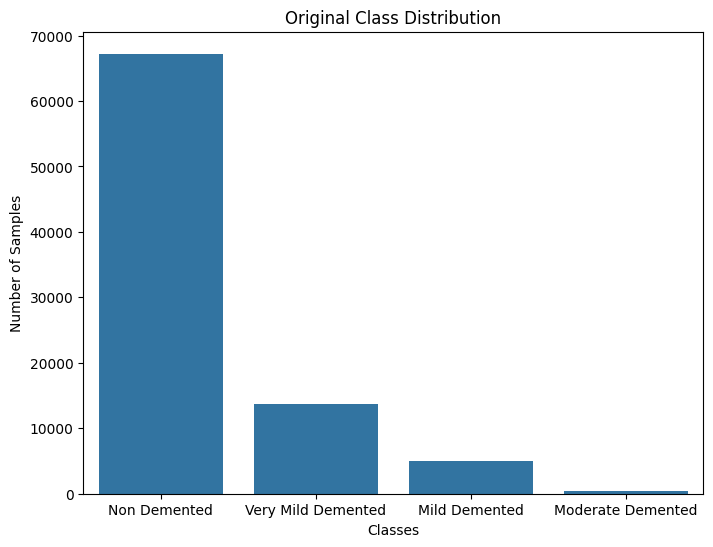

In [ ]:
# Barplot for class distribution
class_names = ["Non Demented", "Very Mild Demented", "Mild Demented", "Moderate Demented"]
class_counts = Counter(labels)
print("Original class distribution:", class_counts)

plt.figure(figsize=(8, 6))
sns.barplot(x=class_names, y=[class_counts[i] for i in range(4)])
plt.xlabel("Classes")
plt.ylabel("Number of Samples")
plt.title("Original Class Distribution")
plt.show()

In [ ]:
# Splitting the data into train and test
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.3, stratify=labels, random_state=42
)

In [ ]:
# Feature Extraction
def extract_features(image_paths, batch_size=32):
    model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    features = []
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i+batch_size]
        batch_images = [preprocess_input(img_to_array(load_img(p, target_size=(128, 128)))) for p in batch_paths]
        batch_images = np.array(batch_images)
        batch_features = model.predict(batch_images, verbose=0)
        batch_features = batch_features.reshape(batch_features.shape[0], -1)
        features.extend(batch_features)
    return np.array(features)

# Extract features
train_features = extract_features(train_paths)
test_features = extract_features(test_paths)

train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

In [ ]:
# SMOTE for Balancing the Dataset
encoder = LabelEncoder()
train_labels_encoded = encoder.fit_transform(train_labels)

smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(train_features, train_labels_encoded)
y_resampled = to_categorical(y_resampled)

print("Resampled shape:", x_resampled.shape)
print("Resampled class distribution:", Counter(np.argmax(y_resampled, axis=1)))

Resampled shape: (188220, 8192)
Resampled class distribution: Counter({np.int64(0): 47055, np.int64(1): 47055, np.int64(3): 47055, np.int64(2): 47055})


In [ ]:
# Defined CNN Model
from tensorflow.keras.regularizers import l2

def create_model(input_shape, num_classes):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(x_resampled.shape[1],), kernel_regularizer=l2(0.001)),
        Dropout(0.6),
        Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.6),
        Dense(y_resampled.shape[1], activation='softmax')
     ])


    optimizer = Adam(learning_rate=1e-4)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = create_model(x_resampled.shape[1], y_resampled.shape[1])
model.summary()

c:\Users\yashw\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,130,820 (8.13 MB)

 Trainable params: 2,130,820 (8.13 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
# Train Model on Re-sampled Data

from tensorflow.keras.callbacks import ModelCheckpoint

# Define the checkpoint to save the best model
checkpoint = ModelCheckpoint(
    'best_model.keras',               
    monitor='val_loss',             
    mode='min',                     
    save_best_only=True,     
    verbose=1
)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(x_resampled, y_resampled, epochs=35, batch_size=32, validation_split=0.2, callbacks=[early_stopping, checkpoint])


Epoch 1/35
4704/4706 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9158 - loss: 0.2849
Epoch 1: val_loss improved from inf to 0.05066, saving model to best_model.keras
4706/4706 ━━━━━━━━━━━━━━━━━━━━ 88s 19ms/step - accuracy: 0.9158 - loss: 0.2849 - val_accuracy: 1.0000 - val_loss: 0.0507
Epoch 2/35
4706/4706 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9289 - loss: 0.2478
Epoch 2: val_loss did not improve from 0.05066
4706/4706 ━━━━━━━━━━━━━━━━━━━━ 71s 15ms/step - accuracy: 0.9289 - loss: 0.2478 - val_accuracy: 1.0000 - val_loss: 0.0523
Epoch 3/35
4706/4706 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9387 - loss: 0.2248
Epoch 3: val_loss did not improve from 0.05066
4706/4706 ━━━━━━━━━━━━━━━━━━━━ 78s 17ms/step - accuracy: 0.9387 - loss: 0.2248 - val_accuracy: 1.0000 - val_loss: 0.0528
Epoch 4/35
4704/4706 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9449 - loss: 0.2106
Epoch 4: val_loss did not improve from 0.05066
4706/4706 ━━━━━━━━━━━━━━━━━━━━ 80s 17ms/step - accuracy: 0.

In [ ]:
# Evaluation on Test Set
test_labels_encoded = to_categorical(encoder.transform(test_labels))
test_loss, test_accuracy = model.evaluate(test_features, test_labels_encoded)
print(f"Test Accuracy: {test_accuracy:.4f}")

811/811 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9475 - loss: 0.1645
Test Accuracy: 0.9489


In [ ]:
# Prediction and Evaluation
y_pred = model.predict(test_features)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(test_labels_encoded, axis=1)
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

811/811 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
                    precision    recall  f1-score   support

      Non Demented       0.99      0.94      0.97     20167
Very Mild Demented       0.79      0.97      0.87      4118
     Mild Demented       0.92      0.98      0.95      1501
 Moderate Demented       0.99      0.98      0.98       146

          accuracy                           0.95     25932
         macro avg       0.92      0.97      0.94     25932
      weighted avg       0.96      0.95      0.95     25932



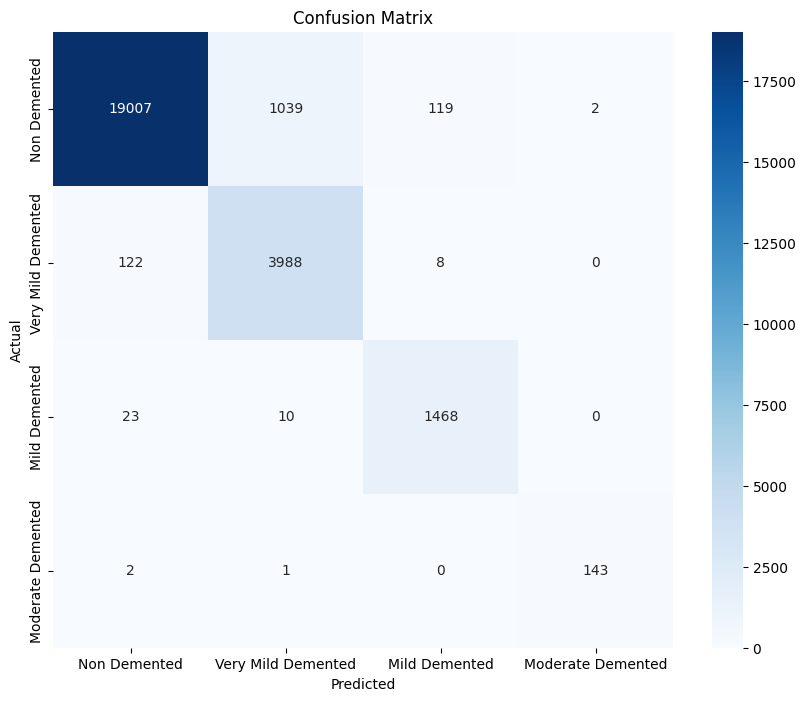

In [50]:
# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
